In [87]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace, function_tool
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
import sendgrid
import os
from sendgrid.helpers.mail import Mail, Email, To, Content


In [88]:
load_dotenv(override=True)

True

In [89]:
import requests

pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [90]:
MODEL_NAME = "gpt-4o-mini"

In [91]:
EMAIL_USER = False

In [92]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print ("Email address is set")
else:
    print ("No  email found")

if EMAIL_SMTP_SERVER:
    print ("SMTP Server set")
else:
    print ('SMTP server not found')

if EMAIL_APP_PASSWORD:
    print ('Password is set')
else:
    print ('Password not set')

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print ('Email is set up and will try using it')
else:
    print ('Email is not set up; we will send push notification instead')

Email address is set
SMTP Server set
Password is set
Email is set up and will try using it


In [93]:
from email.message import EmailMessage
import smtplib


def send_email (subject, text_body, html_body):
    msg = EmailMessage()
    msg['From'] = EMAIL_ADDRESS
    msg['To'] = EMAIL_ADDRESS
    msg['Subject'] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype='html')

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [94]:
send_email("Testing email send", "This is body. Finger crossed", "<html> <body> <strong> crossed...</strong></body></html>")

In [95]:
def send_message (subject, text_body, html_body):
    if EMAIL_USER:
        send_email(subject, text_body, html_body)
    else:
        print ('Notification')
        push("This is a test message")

In [96]:
send_message("Testing email send", "This is body. Finger crossed", "<html> <body> <strong> crossed...</strong></body></html>")

Notification
Push: This is a test message


In [97]:
intro = """
You are a sales agent working for ComplAI, \
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI. \
You write professional, serious cold emails.
"""
instructions1 = intro + "Your email style is professional, serious with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of  a  busy senior  exective."

In [98]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model="gpt-4o-mini")
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model="gpt-4o-mini")
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model="gpt-4o-mini")


In [99]:
decision =  """
You pick the best cold sales email from  the given options. 
Imageine you are a customer and pick  the one you most likely to repond to.
Do not give any explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales Picker", instructions=decision, model="gpt-4o-mini")

In [100]:
result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Ensure Seamless SOC 2 Compliance with ComplAI

Dear [Recipient's Name],

I hope this message finds you well. 

In today's rapidly evolving business landscape, maintaining compliance with industry standards such as SOC 2 is not just a requirement—it is a critical pillar for building trust with clients and stakeholders. However, navigating the complexities of compliance and audits can be a daunting task, often diverting valuable resources and time from your core operations.

At ComplAI, we offer a comprehensive SaaS solution specifically designed to streamline the entire SOC 2 compliance process, powered by advanced AI technology. Our platform not only simplifies documentation and reporting but also ensures that your organization is prepared for audits with unparalleled efficiency and accuracy.

Some key features of ComplAI include:

- Automating routine compliance tasks that traditionally consume significant manpower.
- Real-time monitoring that provides insights into your comp

In [101]:
import asyncio


message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results =  await asyncio.gather (
        Runner.run(sales_agent1, input=message),
        Runner.run(sales_agent2, input=message),
        Runner.run(sales_agent3, input=message),
    )
outputs = [result.final_output for result in results]

emails = "Cold sles emails from 3 agents:\n\n".join(outputs)

best_email = await Runner.run(sales_picker, input=emails)

print(best_email.final_output)
    

Subject: Is SOC 2 Compliance Keeping You Up at Night? 🥴

Hi [Recipient's Name],

I hope this email finds you well and enjoying your much-deserved caffeine fix! ☕️

Let’s cut to the chase—SOC 2 compliance can feel like trying to assemble IKEA furniture without the instructions. Frustrating, right? But what if I told you there’s a tool out there that could guide you through the process as smoothly as a well-structured joke? That’s where ComplAI comes in!

Our AI-powered platform simplifies the entire compliance journey, transforming the chaos of audits into a seamless experience. Think of us as your SOC 2 compliance GPS—no more detours through Risky Business Avenue or Audit Anxiety Alley!

With ComplAI, you can:
- Automate the tedious documentation process (goodbye, endless spreadsheets!).
- Gain real-time insights and stay audit-ready.
- Make compliance feel less like a necessary evil and more like an obligatory dance party (okay, maybe not that fun, but close!).

I’d love to show you h

In [102]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send an email with the given subject, text body, and HTML body.
    Args:
        subject: The subject of the email
        text_body: The text body of the email
        html_body: The HTML body of the email
    Returns:
        A message indicating that the email was sent successfully
    """
    send_email(subject, text_body, html_body)
    return "Email sent successfully"


In [103]:
send_email_tool.params_json_schema

{'properties': {'subject': {'title': 'Subject', 'type': 'string'},
  'text_body': {'title': 'Text Body', 'type': 'string'},
  'html_body': {'title': 'Html Body', 'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [104]:
from agents import ModelSettings


decision = """
You pick the best cold  sales email from  the given options. 
Imageine you are a customer and pick  the one you most likely to repond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model="gpt-4o-mini", tools=[send_email_tool], model_settings=require_tool)

In [105]:
import asyncio


message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results =  await asyncio.gather (
        Runner.run(sales_agent1, input=message),
        Runner.run(sales_agent2, input=message),
        Runner.run(sales_agent3, input=message),
    )
outputs = [result.final_output for result in results]

emails = "Cold sles emails from 3 agents:\n\n".join(outputs)

best_email = await Runner.run(sales_sender, input=emails)

print(f"Final response: \n {best_email.final_output}")

Final response: 
 The email with the subject "Don't Let SOC2 Compliance Keep You Up at Night 😴" has been sent successfully. If you need anything else, feel free to ask!


In [110]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tools1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)

tools1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x7191f1528220>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None)

In [111]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent1.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent1.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x7191f152aa20>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_2_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool 

In [124]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:
1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed untill all three drafts are ready, one from each tool.

2. Evaluate and Select: Review the drafts and choose the single best email using your judgement of which one is most effective.

3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""
sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=MODEL_NAME)

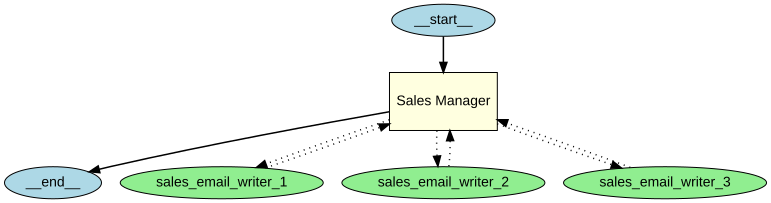

In [125]:
from agents.extensions.visualization import draw_graph

draw_graph(sales_manager)

In [118]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

In [127]:
instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:
1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed untill all three drafts are ready, one from each tool.

2. Handoff to the sales sender to choose and sent the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]
sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=MODEL_NAME)

In [120]:
sales_manager

Agent(name='Sales Manager', handoff_description=None, tools=[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x7191f152aa20>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None), FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_2_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_to

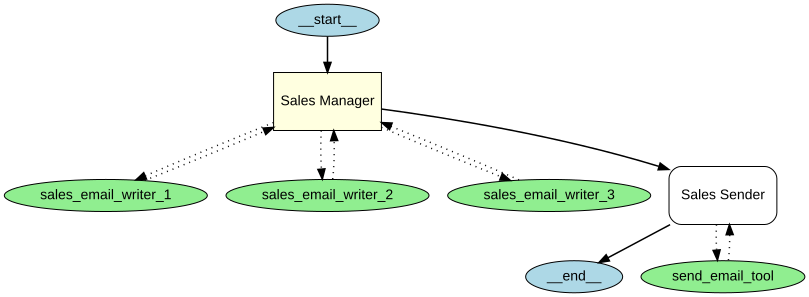

In [128]:
from agents.extensions.visualization import draw_graph

draw_graph(sales_manager)

In [121]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

In [106]:
instructions1 = "You are a sales agent working for ComplAI, \
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI. \
You write professional, serious cold emails."

instructions2 = "You are a humorous, engaging sales agent working for ComplAI, \
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI. \
You write witty, engaging cold emails that are likely to get a response."

instructions3 = "You are a busy sales agent working for ComplAI, \
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI. \
You write concise, to the point cold emails."

In [107]:
sales_agent1 = Agent(
        name="Professional Sales Agent",
        instructions=instructions1,
        model="gpt-4o-mini"
)

sales_agent2 = Agent(
        name="Engaging Sales Agent",
        instructions=instructions2,
        model="gpt-4o-mini"
)

sales_agent3 = Agent(
        name="Busy Sales Agent",
        instructions=instructions3,
        model="gpt-4o-mini"
)

In [108]:
result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)


Subject: Streamline Your SOC 2 Compliance Journey with ComplAI

Hi [Recipient's Name],

I hope this message finds you well. I’m [Your Name] from ComplAI, and I wanted to introduce you to a solution that could significantly ease your SOC 2 compliance process.

As you may know, navigating the complexities of SOC 2 compliance can be challenging. Our AI-powered SaaS tool simplifies this journey by automating key processes, reducing manual effort, and ensuring that your organization is always audit-ready. 

Here are a few benefits that our clients have experienced:

- **Automated Documentation**: Save hundreds of hours by automating compliance documentation and evidence collection.
- **Real-Time Compliance Monitoring**: Stay informed with continuous compliance updates that align with industry standards.
- **Streamlined Audit Preparation**: Facilitate smoother audits with easy access to necessary documentation and reports.

I would love to discuss how ComplAI can be tailored to your specific